In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from persiantools.jdatetime import JalaliDate
from datetime import datetime
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import openpyxl
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import Label
from bokeh.models import ColumnDataSource
from bokeh.transform import dodge
from bokeh.io import output_notebook
from bokeh.models import NumeralTickFormatter
from bokeh.models import Label
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import re
import random
import matplotlib as mpl
import seaborn as sns
import numpy as np
df = pd.read_excel("/Users/mohammad/XAV/Departemant Financial/Receipt Database.xlsx")


## Basic Functions

In [2]:
def persian_to_gregorian(persian_date_str):
    # Split the Persian date string by '/'
    year, month, day = map(int, persian_date_str.split('/'))
    # Create a JalaliDate object
    persian_date = JalaliDate(year, month, day)
    # Convert to Gregorian date
    gregorian_date = persian_date.to_gregorian()
    # Return the Gregorian date in 'YYYY-MM-DD' format
    return gregorian_date.strftime('%Y-%m-%d')


def days_until_target(date_str, target_date_str="2024-09-20"):
    # Parse the input date string to a datetime object
    start_date = datetime.strptime(date_str, "%Y-%m-%d")
    # Parse the target date (default is "2024-09-20")
    target_date = datetime.strptime(target_date_str, "%Y-%m-%d")
    # Calculate the difference in days
    days_difference = (target_date - start_date).days
    # Return the number of days
    return days_difference

## Time Series Analysis

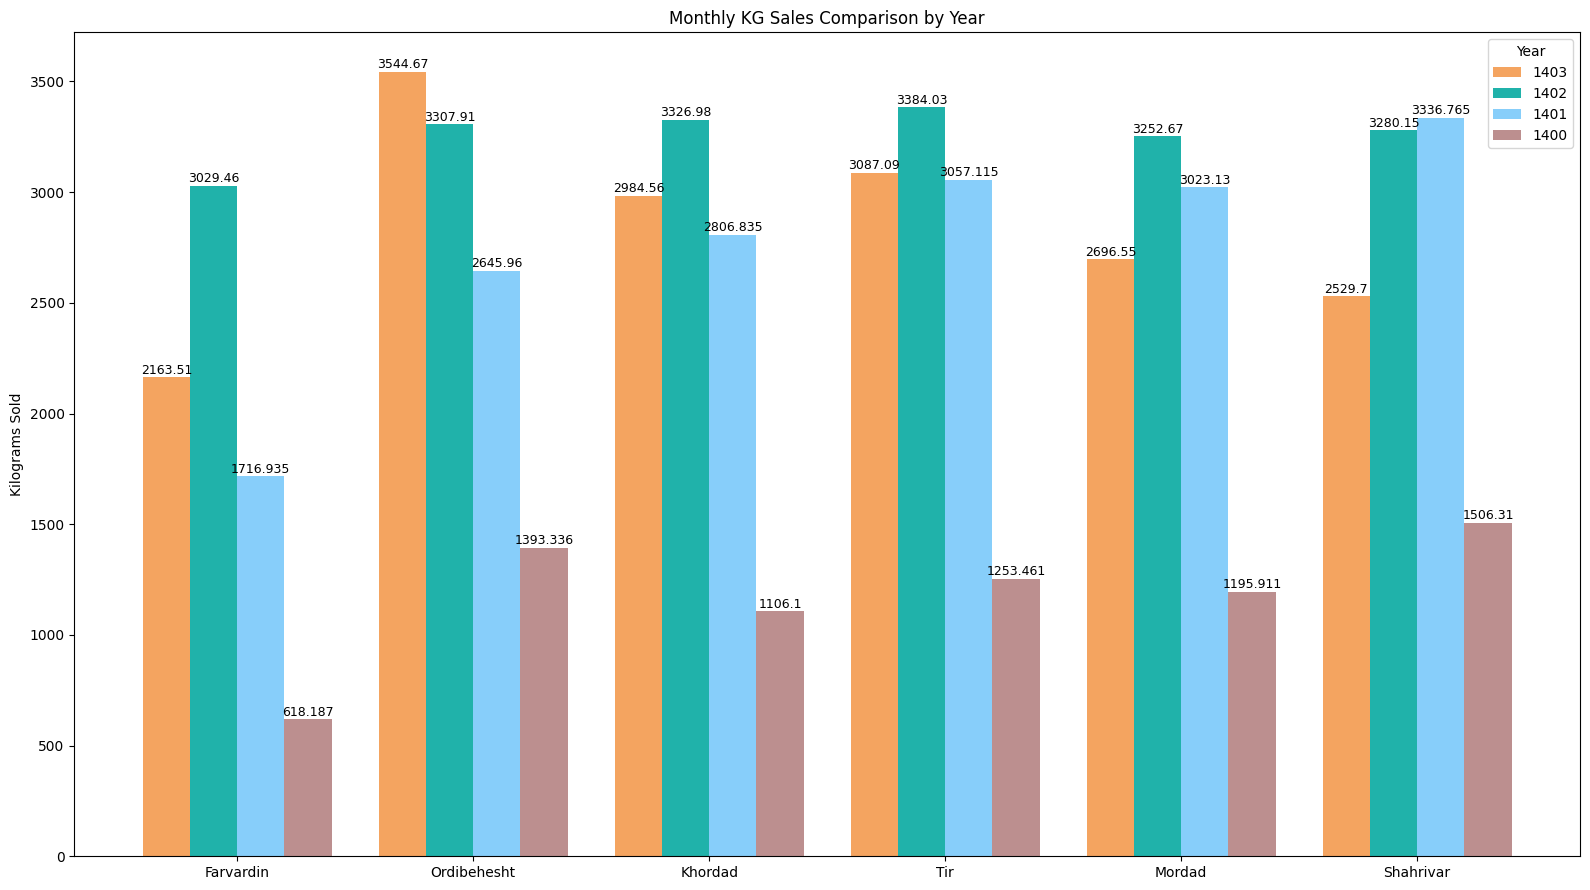

In [3]:
# creating a def to create a dict for each year ({month : kg})
def monthly_buy (year):
    year_dict = {}
    mask_year = df["تاريخ"].str.startswith(year)
    df_year = df[mask_year]
    df_year = df_year[df_year["نوع فروش"] == "قهوه و لوازم جانبي"]

    # months list 
    months_list = list(set(df_year["ماه"].to_list()))
    # adding Each month kg sale to dict
    for i in months_list:
        kg = round(sum(df_year[df_year["ماه"]==i]["مقدار-فرعي"].to_list())/1000,3)
        year_dict[i] = kg
    return year_dict

monthly_kg_1403 = list(monthly_buy("1403").values())[:6]
monthly_kg_1402 = list(monthly_buy("1402").values())[:6]
monthly_kg_1401 = list(monthly_buy("1401").values())[:6]
monthly_kg_1400 = list(monthly_buy("1400").values())[:6]

yearly_kg_dict = {1403: monthly_kg_1403, 1402:monthly_kg_1402, 1401:monthly_kg_1401 , 1400:monthly_kg_1400 }


# Persian month names
months = ['Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar']

# Plotting
x = np.arange(len(months))  # Month positions on x-axis
width = 0.2  # Bar width
# Updated colors with nude tones
colors = ['sandybrown', 'lightseagreen', 'lightskyblue', 'rosybrown']

fig, ax = plt.subplots(figsize=(16, 9))

for i, (year, data) in enumerate(yearly_kg_dict.items()):
    bars = ax.bar(x + i * width, data, width, label=str(year), color=colors[i])
    # Adding value annotations on top of each bar
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # X position
            bar.get_height() + 2,  # Y position (slightly above the bar)
            f'{bar.get_height()}',  # Text to display
            ha='center',  # Horizontal alignment
            va='bottom',  # Vertical alignment
            fontsize=9
        )

# Customizing the plot
ax.set_ylabel('Kilograms Sold')
ax.set_title('Monthly KG Sales Comparison by Year')
ax.set_xticks(x + width * (len(yearly_kg_dict) - 1) / 2)
ax.set_xticklabels(months)
ax.legend(title="Year")

plt.tight_layout()
plt.show()  


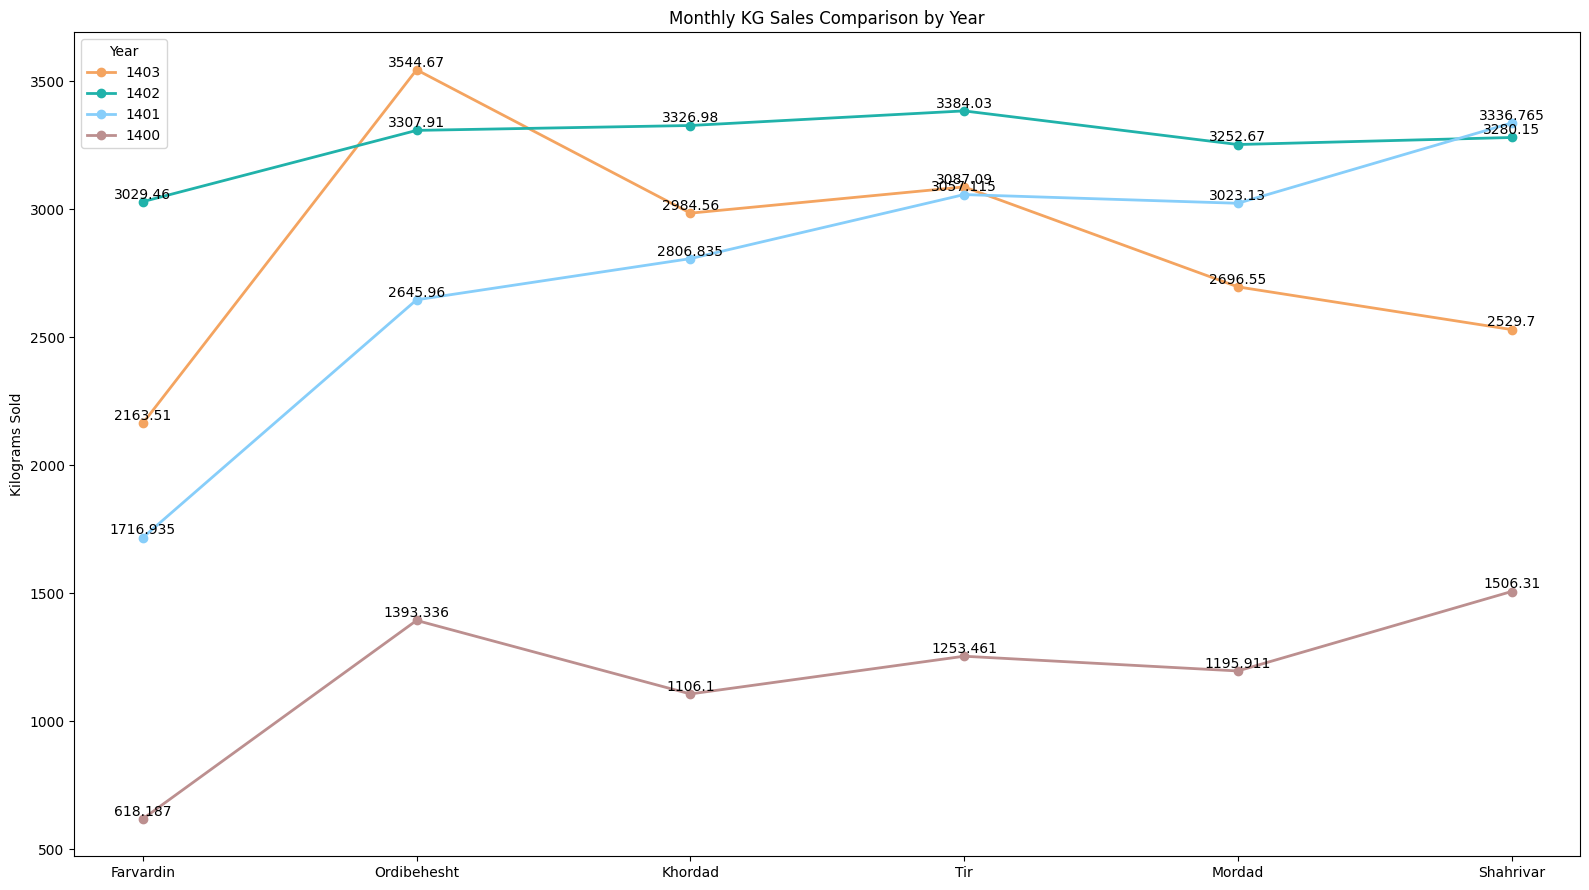

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Create a function to create a dict for each year ({month: kg})
def monthly_buy(year):
    year_dict = {}
    mask_year = df["تاريخ"].str.startswith(year)
    df_year = df[mask_year]
    df_year = df_year[df_year["نوع فروش"] == "قهوه و لوازم جانبي"]

    # months list 
    months_list = list(set(df_year["ماه"].to_list()))
    # Adding each month's kg sale to dict
    for i in months_list:
        kg = round(sum(df_year[df_year["ماه"] == i]["مقدار-فرعي"].to_list()) / 1000, 3)
        year_dict[i] = kg
    return year_dict

monthly_kg_1403 = list(monthly_buy("1403").values())[:6]
monthly_kg_1402 = list(monthly_buy("1402").values())[:6]
monthly_kg_1401 = list(monthly_buy("1401").values())[:6]
monthly_kg_1400 = list(monthly_buy("1400").values())[:6]

yearly_kg_dict = {1403: monthly_kg_1403, 1402: monthly_kg_1402, 1401: monthly_kg_1401, 1400: monthly_kg_1400}

# Persian month names
months = ['Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar']

# Plotting
x = np.arange(len(months))  # Month positions on x-axis

# Updated colors with soft tones
colors = ['sandybrown', 'lightseagreen', 'lightskyblue', 'rosybrown']

fig, ax = plt.subplots(figsize=(16, 9))

# Plot each year as a line chart
for i, (year, data) in enumerate(yearly_kg_dict.items()):
    ax.plot(x, data, label=str(year), color=colors[i], marker='o', linestyle='-', linewidth=2)

# Customizing the plot
ax.set_ylabel('Kilograms Sold')
ax.set_title('Monthly KG Sales Comparison by Year')
ax.set_xticks(x)
ax.set_xticklabels(months)
ax.legend(title="Year")

# Display values on the line
for i, (year, data) in enumerate(yearly_kg_dict.items()):
    for j, value in enumerate(data):
        ax.text(x[j], value + 0.5, str(value), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# Descriptive Analysis

In [6]:
print("avg in 1403 -->", sum(monthly_kg_1403) / 6)
print("avg in 1402 -->", sum(monthly_kg_1402) / 6)
print("avg in 1401 -->", sum(monthly_kg_1401) / 6)


avg in 1403 --> 2834.346666666667
avg in 1402 --> 3263.5333333333333
avg in 1401 --> 2764.456666666667


410 Tedad kolle cafe 1403
160 Tedad Cafe hayi k bish az 10 kg majmooan kharid karde bashan dar in 6 mah
73 Tedad Cafe hayi k bish az 40 kg majmooan kharid karde bashan dar in 6 mah
36 Tedad Cafe hayi k bish az 100 kg majmooan kharid karde bashan dar in 6 mah
20 Tedad Cafe hayi k bish az 200 kg majmooan kharid karde bashan dar in 6 mah
8 Tedad Cafe hayi k bish az 400 kg majmooan kharid karde bashan dar in 6 mah
3 Tedad Cafe hayi k bish az 600 kg majmooan kharid karde bashan dar in 6 mah
1 Tedad Cafe hayi k bish az 900 kg majmooan kharid karde bashan dar in 6 mah


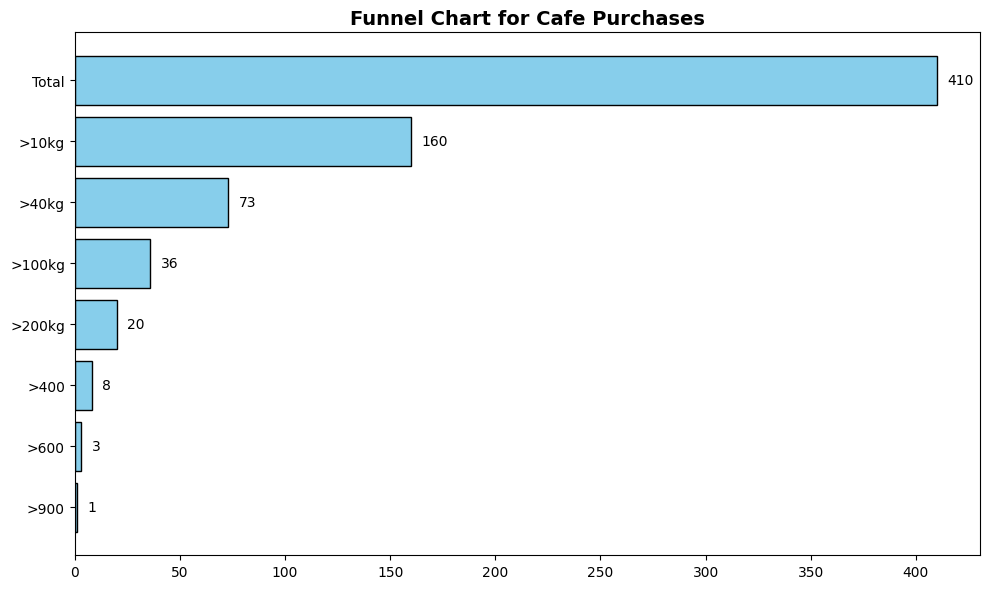

---------------------------------------------------------------------------------

408 Tedad kolle cafe 1402
171 Tedad Cafe hayi k bish az 10 kg majmooan kharid karde bashan dar in 6 mah
79 Tedad Cafe hayi k bish az 40 kg majmooan kharid karde bashan dar in 6 mah
45 Tedad Cafe hayi k bish az 100 kg majmooan kharid karde bashan dar in 6 mah
23 Tedad Cafe hayi k bish az 200 kg majmooan kharid karde bashan dar in 6 mah
8 Tedad Cafe hayi k bish az 400 kg majmooan kharid karde bashan dar in 6 mah
4 Tedad Cafe hayi k bish az 600 kg majmooan kharid karde bashan dar in 6 mah
2 Tedad Cafe hayi k bish az 900 kg majmooan kharid karde bashan dar in 6 mah


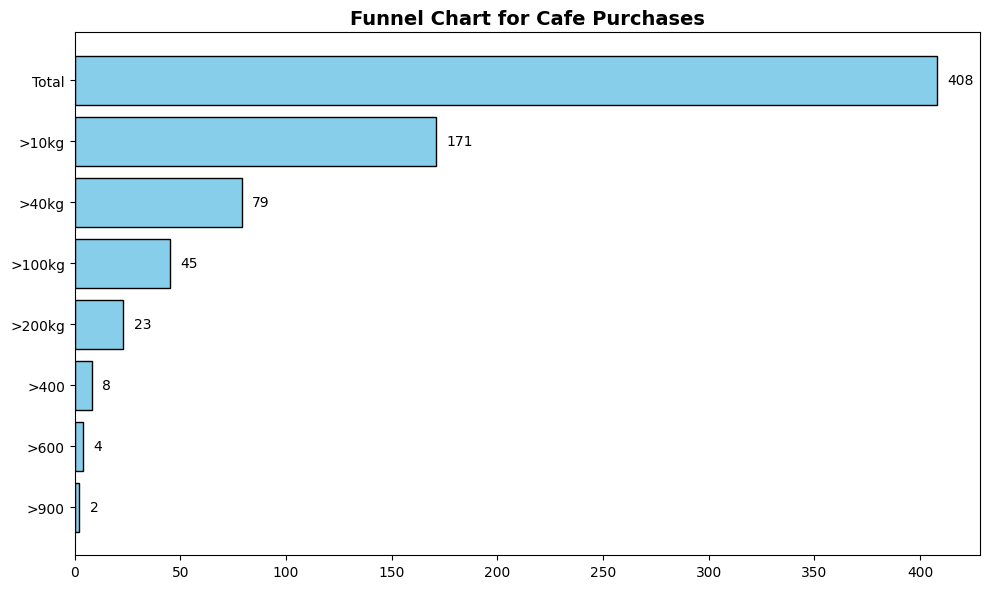

---------------------------------------------------------------------------------

242 Tedad kolle cafe 1401
126 Tedad Cafe hayi k bish az 10 kg majmooan kharid karde bashan dar in 6 mah
75 Tedad Cafe hayi k bish az 40 kg majmooan kharid karde bashan dar in 6 mah
34 Tedad Cafe hayi k bish az 100 kg majmooan kharid karde bashan dar in 6 mah
22 Tedad Cafe hayi k bish az 200 kg majmooan kharid karde bashan dar in 6 mah
9 Tedad Cafe hayi k bish az 400 kg majmooan kharid karde bashan dar in 6 mah
4 Tedad Cafe hayi k bish az 600 kg majmooan kharid karde bashan dar in 6 mah
1 Tedad Cafe hayi k bish az 900 kg majmooan kharid karde bashan dar in 6 mah


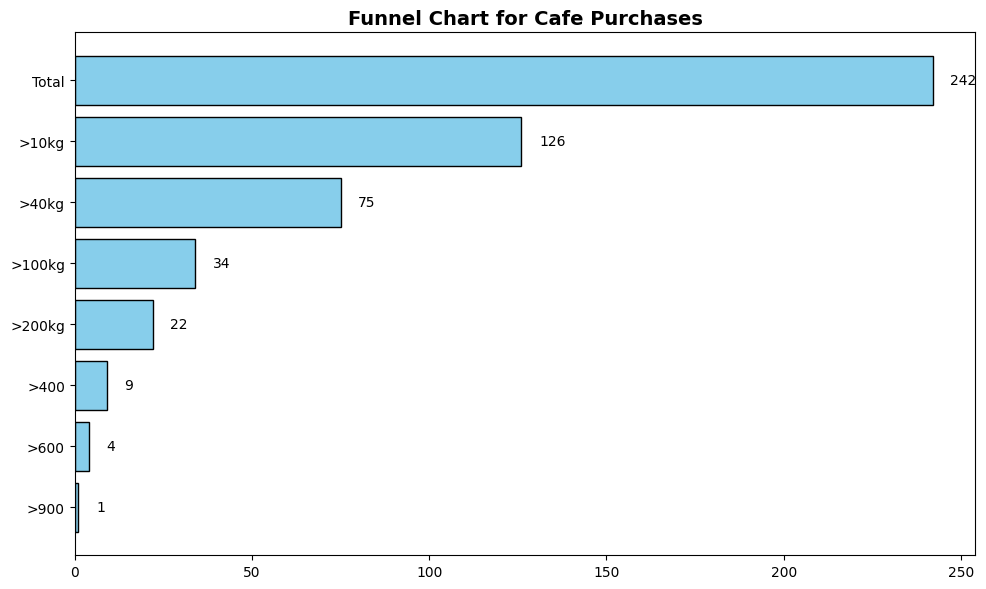

---------------------------------------------------------------------------------



In [7]:
# Number of cafes 
df = pd.read_excel("/Users/mohammad/XAV/Departemant Financial/Receipt Database.xlsx")
df = df[df["ماه"] < 7]
def descriptive(year):

    mask_1403 = df["تاريخ"].str.startswith(year)
    df_1403 = df[mask_1403]

    # selecting cafes buy list 
    df_1403 = df_1403[df_1403["كد گروه مشتري"]==2]
    cafe_list = set(df_1403["مشتري"].to_list())
    print(len(cafe_list), f"Tedad kolle cafe {year}")


    # creating a dict for each cafe 
    cafe_list = set(df_1403["مشتري"].to_list())
    cafe_dict = {}
    for i in cafe_list:
        cafe_df = df_1403[df_1403["مشتري"]==i]
        cafe_buy = round(sum(cafe_df["مقدار-فرعي"].to_list())/1000,3)
        cafe_dict[i] = cafe_buy


    # creatng data frame of cafes
    cafe_df = pd.DataFrame(list(cafe_dict.items()), columns=['Cafe', 'KG-6'])
    print(len(cafe_df[cafe_df["KG-6"]>10]["Cafe"].to_list()), "Tedad Cafe hayi k bish az 10 kg majmooan kharid karde bashan dar in 6 mah")
    print(len(cafe_df[cafe_df["KG-6"]>40]["Cafe"].to_list()), "Tedad Cafe hayi k bish az 40 kg majmooan kharid karde bashan dar in 6 mah")
    print(len(cafe_df[cafe_df["KG-6"]>100]["Cafe"].to_list()), "Tedad Cafe hayi k bish az 100 kg majmooan kharid karde bashan dar in 6 mah")
    print(len(cafe_df[cafe_df["KG-6"]>200]["Cafe"].to_list()), "Tedad Cafe hayi k bish az 200 kg majmooan kharid karde bashan dar in 6 mah")
    print(len(cafe_df[cafe_df["KG-6"]>400]["Cafe"].to_list()), "Tedad Cafe hayi k bish az 400 kg majmooan kharid karde bashan dar in 6 mah")
    print(len(cafe_df[cafe_df["KG-6"]>600]["Cafe"].to_list()), "Tedad Cafe hayi k bish az 600 kg majmooan kharid karde bashan dar in 6 mah")
    print(len(cafe_df[cafe_df["KG-6"]>900]["Cafe"].to_list()), "Tedad Cafe hayi k bish az 900 kg majmooan kharid karde bashan dar in 6 mah")
    # Data for the funnel chart
    labels = ["Total", ">10kg", ">40kg", ">100kg", ">200kg", ">400", ">600", ">900"]
    values = [len(cafe_list),len(cafe_df[cafe_df["KG-6"]>10]["Cafe"].to_list()),
              len(cafe_df[cafe_df["KG-6"]>40]["Cafe"].to_list()),
               len(cafe_df[cafe_df["KG-6"]>100]["Cafe"].to_list()),
               len(cafe_df[cafe_df["KG-6"]>200]["Cafe"].to_list()),
               len(cafe_df[cafe_df["KG-6"]>400]["Cafe"].to_list()),
               len(cafe_df[cafe_df["KG-6"]>600]["Cafe"].to_list()),
               len(cafe_df[cafe_df["KG-6"]>900]["Cafe"].to_list())]

    # Plotting the funnel chart
    plt.figure(figsize=(10, 6))
    plt.barh(labels[::-1], values[::-1], color="skyblue", edgecolor="black")

    # Add labels
    for i, v in enumerate(values[::-1]):
        plt.text(v + 5, i, str(v), va='center', ha='left', fontsize=10)

    # Titles and labels
    plt.title("Funnel Chart for Cafe Purchases", fontsize=14, weight='bold')
    plt.tight_layout()

    # Display the chart
    plt.show()

    print("---------------------------------------------------------------------------------\n")
    return values

descriptive("1403")
descriptive("1402")
descriptive("1401")



import matplotlib.pyplot as plt



410 Tedad kolle cafe 1403
160 Tedad Cafe hayi k bish az 10 kg majmooan kharid karde bashan dar in 6 mah
73 Tedad Cafe hayi k bish az 40 kg majmooan kharid karde bashan dar in 6 mah
36 Tedad Cafe hayi k bish az 100 kg majmooan kharid karde bashan dar in 6 mah
20 Tedad Cafe hayi k bish az 200 kg majmooan kharid karde bashan dar in 6 mah
8 Tedad Cafe hayi k bish az 400 kg majmooan kharid karde bashan dar in 6 mah
3 Tedad Cafe hayi k bish az 600 kg majmooan kharid karde bashan dar in 6 mah
1 Tedad Cafe hayi k bish az 900 kg majmooan kharid karde bashan dar in 6 mah


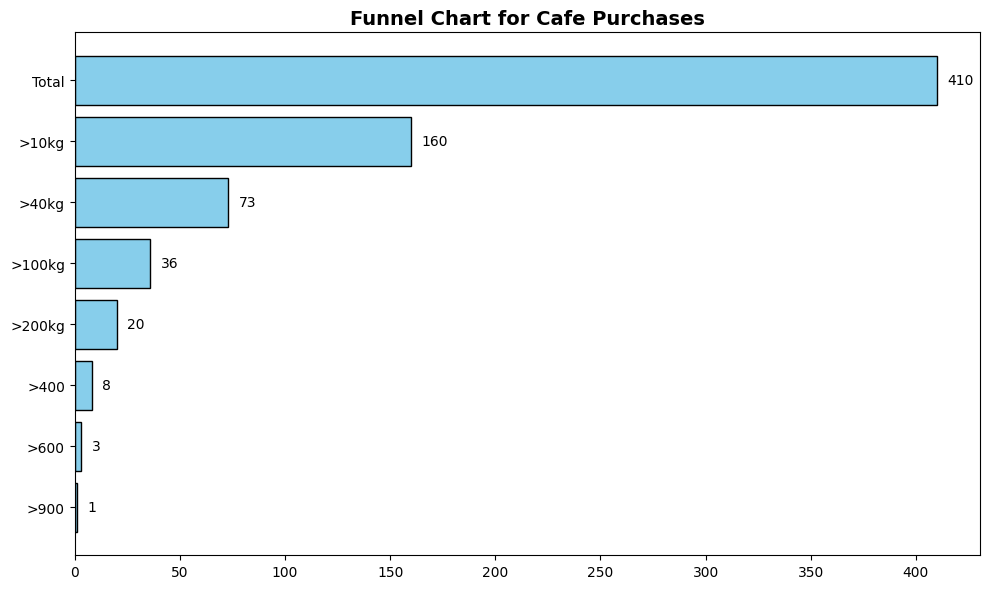

---------------------------------------------------------------------------------

408 Tedad kolle cafe 1402
171 Tedad Cafe hayi k bish az 10 kg majmooan kharid karde bashan dar in 6 mah
79 Tedad Cafe hayi k bish az 40 kg majmooan kharid karde bashan dar in 6 mah
45 Tedad Cafe hayi k bish az 100 kg majmooan kharid karde bashan dar in 6 mah
23 Tedad Cafe hayi k bish az 200 kg majmooan kharid karde bashan dar in 6 mah
8 Tedad Cafe hayi k bish az 400 kg majmooan kharid karde bashan dar in 6 mah
4 Tedad Cafe hayi k bish az 600 kg majmooan kharid karde bashan dar in 6 mah
2 Tedad Cafe hayi k bish az 900 kg majmooan kharid karde bashan dar in 6 mah


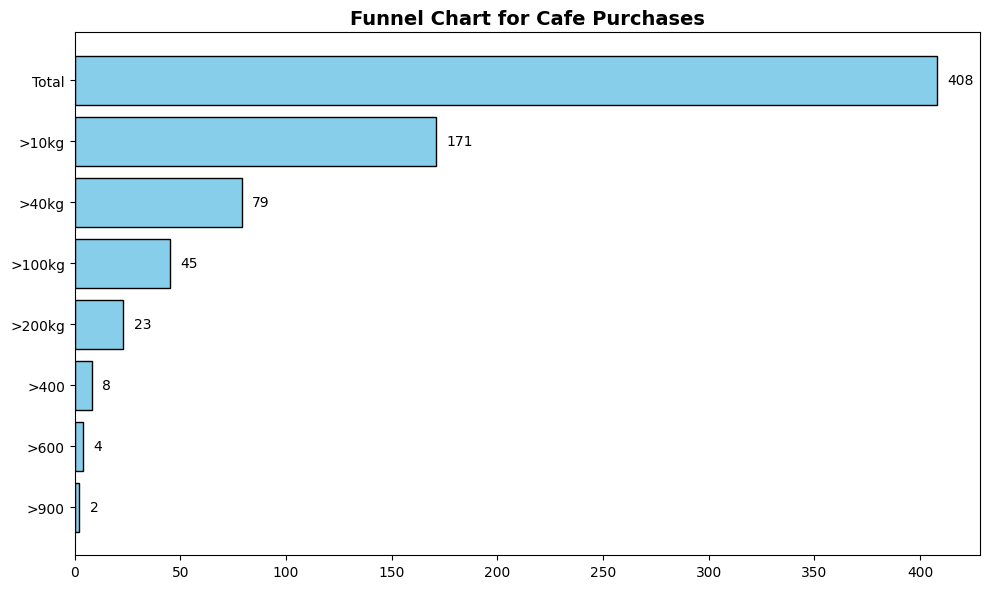

---------------------------------------------------------------------------------

242 Tedad kolle cafe 1401
126 Tedad Cafe hayi k bish az 10 kg majmooan kharid karde bashan dar in 6 mah
75 Tedad Cafe hayi k bish az 40 kg majmooan kharid karde bashan dar in 6 mah
34 Tedad Cafe hayi k bish az 100 kg majmooan kharid karde bashan dar in 6 mah
22 Tedad Cafe hayi k bish az 200 kg majmooan kharid karde bashan dar in 6 mah
9 Tedad Cafe hayi k bish az 400 kg majmooan kharid karde bashan dar in 6 mah
4 Tedad Cafe hayi k bish az 600 kg majmooan kharid karde bashan dar in 6 mah
1 Tedad Cafe hayi k bish az 900 kg majmooan kharid karde bashan dar in 6 mah


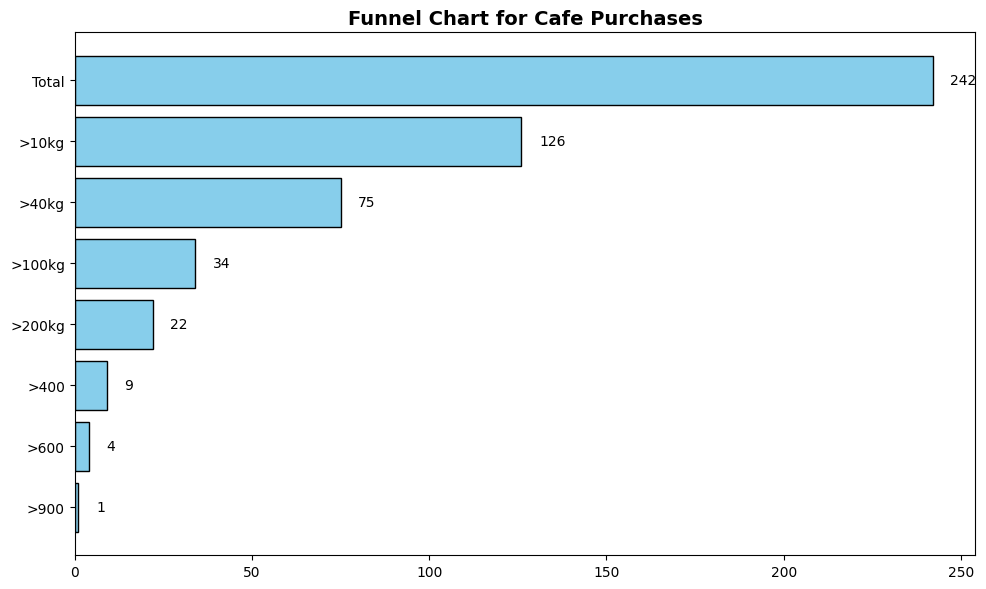

---------------------------------------------------------------------------------



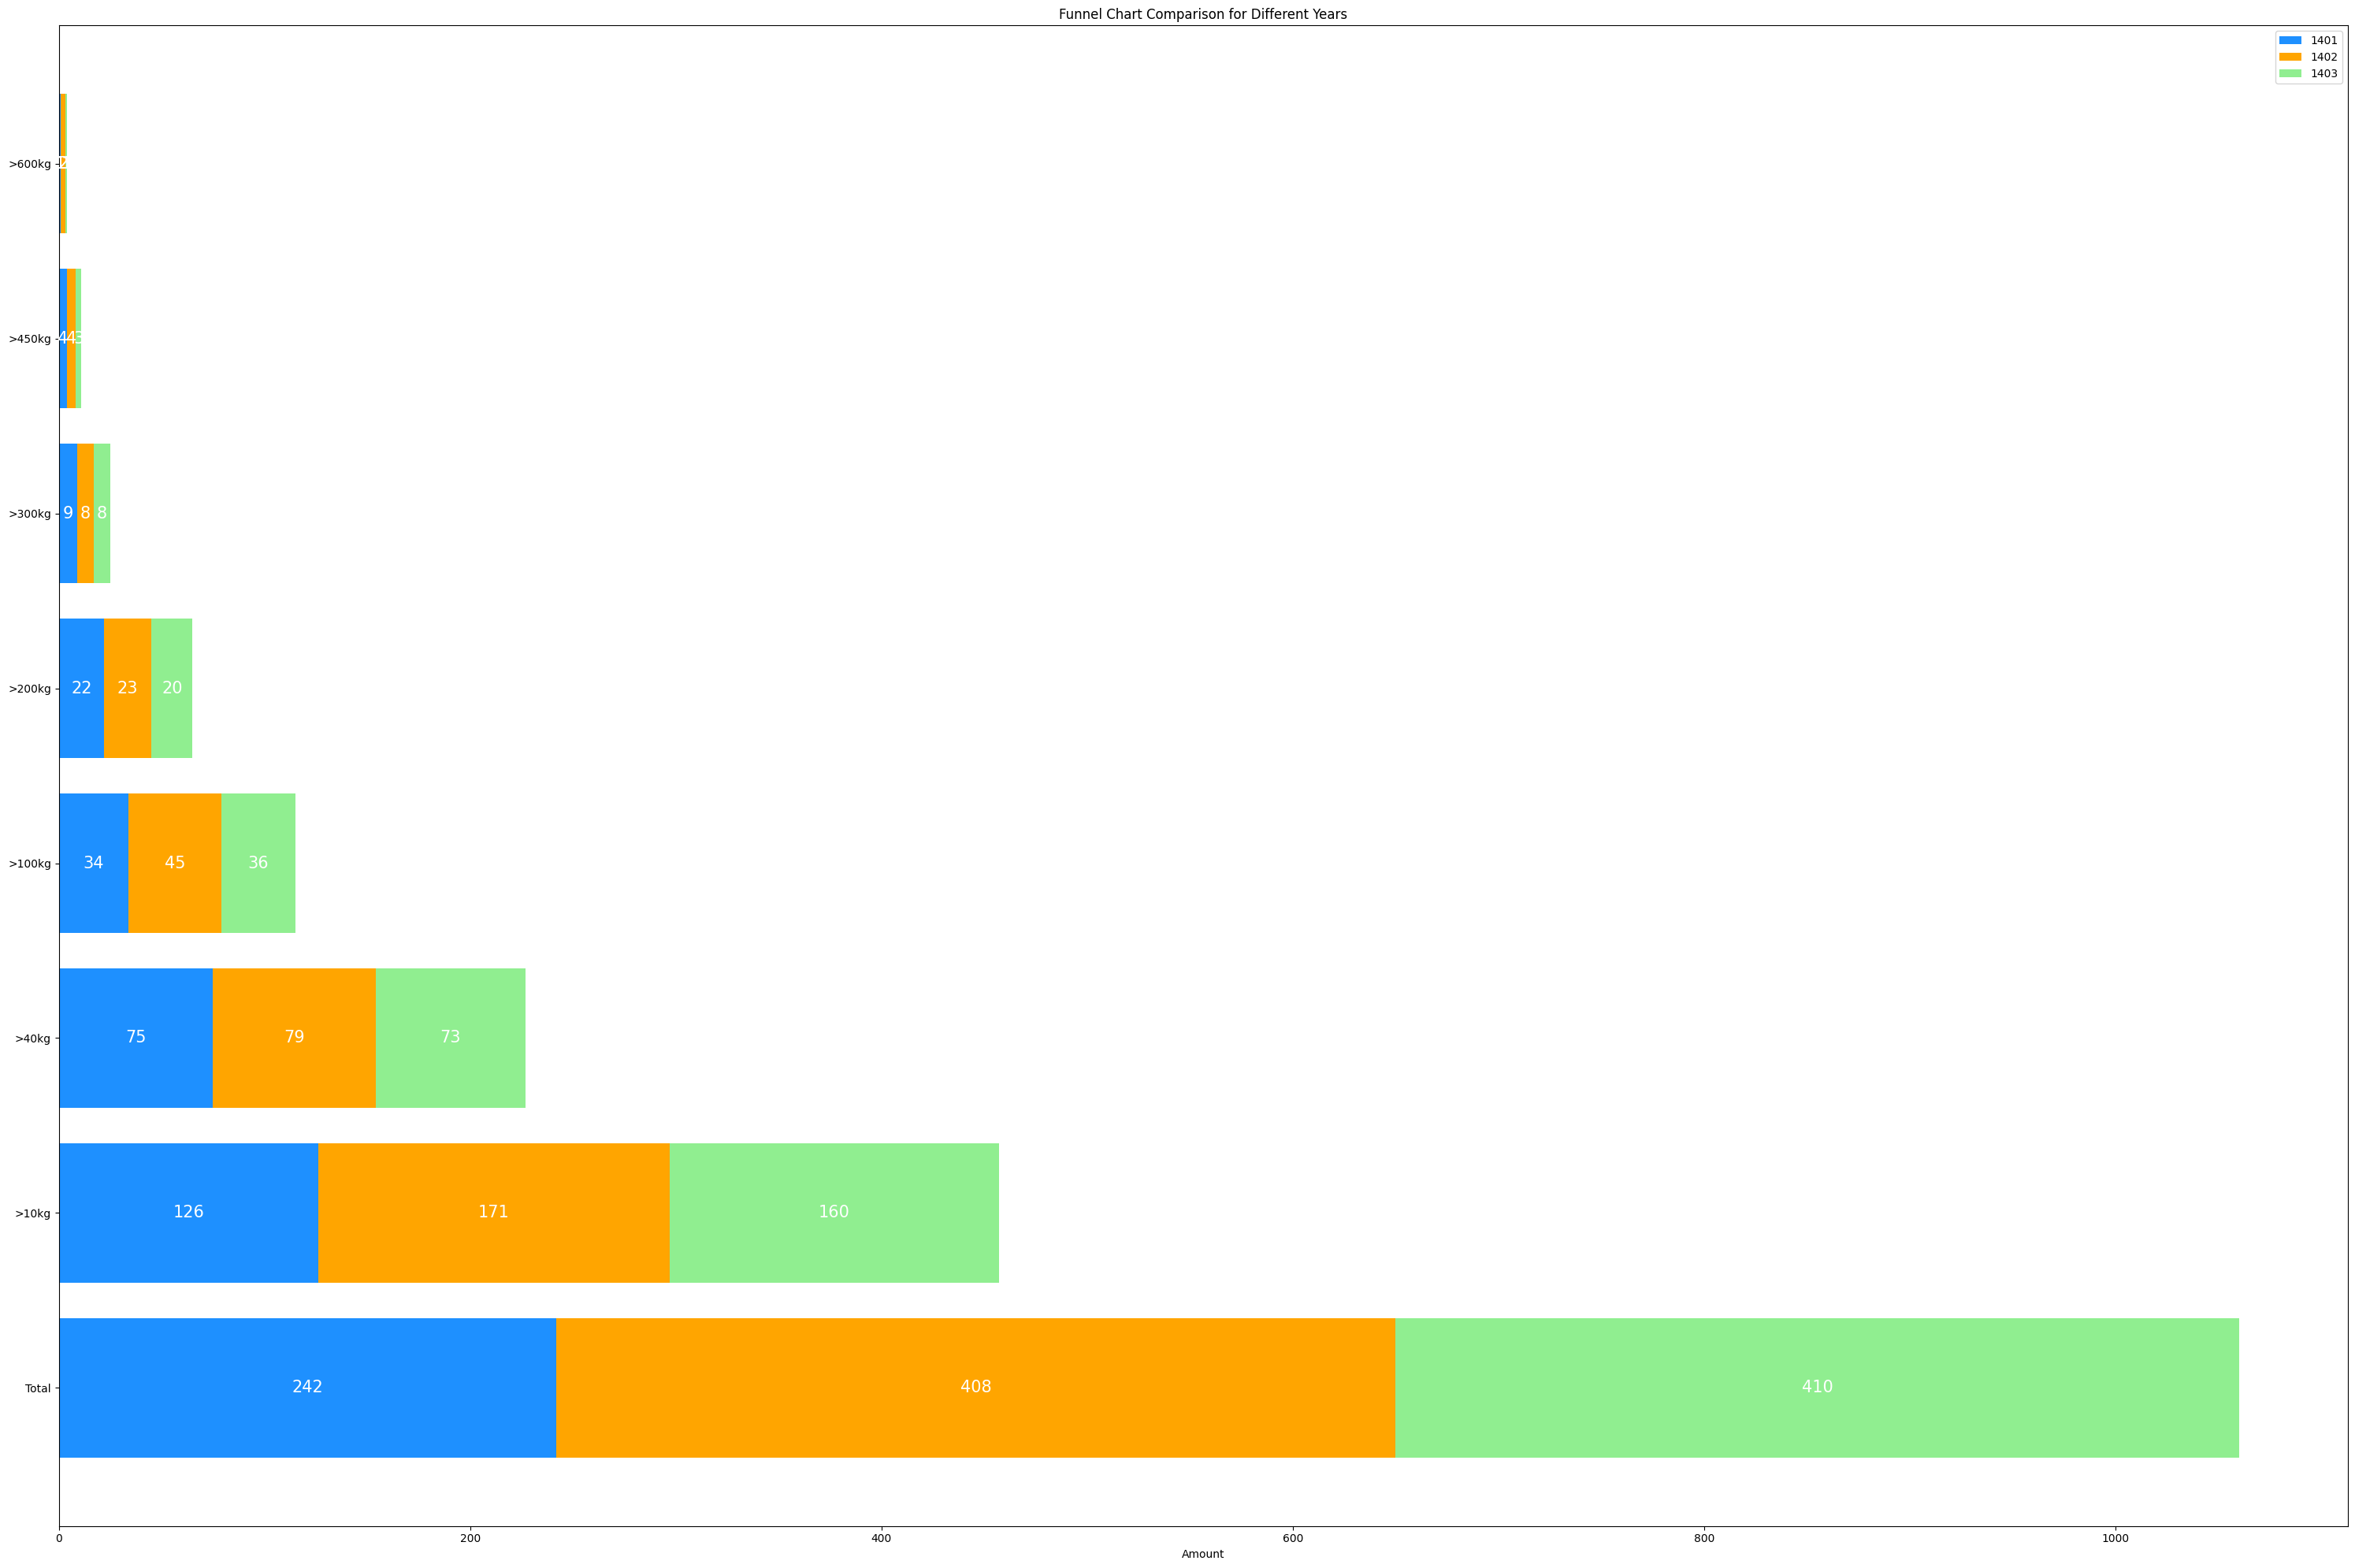

In [93]:
import matplotlib.pyplot as plt
import numpy as np

# Data
values_1403 = descriptive("1403")
values_1402 = descriptive("1402")
values_1401 = descriptive("1401")

# Labels for categories
simplified_labels = ["Total", ">10kg", ">40kg", ">100kg", ">200kg", ">300kg", ">450kg", ">600kg"]
years = ["1403", "1402", "1401"]

# Prepare the data to plot
data = np.array([values_1403, values_1402, values_1401])

# Create the plot
fig, ax = plt.subplots(figsize=(30, 20))

# Set bar positions
y_pos = np.arange(len(simplified_labels))

# Plot each year as a stacked bar
ax.barh(y_pos, data[2], label=years[2], color='dodgerblue')  # 1403
ax.barh(y_pos, data[1], label=years[1], color='orange', left=data[2])  # 1402
ax.barh(y_pos, data[0], label=years[0], color='lightgreen', left=data[2] + data[1])  # 1401

# Add text labels inside the bars
for i in range(len(simplified_labels)):
    ax.text(data[2][i] / 2, i, str(data[2][i]), ha='center', va='center', color='white', fontsize=15)
    ax.text(data[2][i] + data[1][i] / 2, i, str(data[1][i]), ha='center', va='center', color='white', fontsize=15)
    ax.text(data[2][i] + data[1][i] + data[0][i] / 2, i, str(data[0][i]), ha='center', va='center', color='white', fontsize=15)

# Set labels and title
ax.set_yticks(y_pos)
ax.set_yticklabels(simplified_labels)
ax.set_xlabel('Amount')
ax.set_title('Funnel Chart Comparison for Different Years')

# Show legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


# lost cafes within a year

In [8]:
df = pd.read_excel("/Users/mohammad/XAV/Departemant Financial/Receipt Database.xlsx")
df = df[df["ماه"] < 7]

def lost_in_year(year):
# selecting 1403 data
    mask_1403 = df["تاريخ"].str.startswith(year)
    df_1403 = df[mask_1403]

    # selecting cafes buy list 
    df_1403 = df_1403[df_1403["كد گروه مشتري"]==2]

    # creating a dict for each cafe 
    cafe_list = set(df_1403["مشتري"].to_list())
    cafe_dict = {}
    for i in cafe_list:
        cafe_df = df_1403[df_1403["مشتري"]==i]
        cafe_buy = round(sum(cafe_df["مقدار-فرعي"].to_list())/1000,3)
        cafe_dict[i] = cafe_buy


    # creatng data frame of cafes
    cafe_df = pd.DataFrame(list(cafe_dict.items()), columns=['Cafe', 'KG-6'])
    # deleting less than 10kg cafes
    cafe_df = cafe_df[cafe_df["KG-6"]>10]
    # ading segment to each cafe
    cafe_df['segment_percentile'] = pd.qcut(cafe_df['KG-6'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
    cafe_df["receipt_count"] = None
    cafe_df["last_receipt_days_passed"] = None

    # finding first order,last order,number of orders
    for i in set(cafe_df["Cafe"].to_list()):
        cafes_df = df_1403[df_1403["مشتري"]==i]
        receipt_list = list(set(cafes_df["تاريخ"].to_list()))
        first_receipt = receipt_list[0]
        last_receipt = receipt_list[-1]
        receipt_count = len(receipt_list)
        days_since_last_receipt = days_until_target(persian_to_gregorian(last_receipt))
        cafe_df.loc[cafe_df['Cafe'] == i, 'receipt_count'] = receipt_count
        cafe_df.loc[cafe_df['Cafe'] == i, 'last_receipt_days_passed'] = days_since_last_receipt


    print( f"{year} : tedad cafe hayi k bish az 60 rooz az akharin kharideshoon migzare -->", len(cafe_df[cafe_df["last_receipt_days_passed"]>60]))

lost_in_year("1403")
lost_in_year("1402")
lost_in_year("1401")

1403 : tedad cafe hayi k bish az 60 rooz az akharin kharideshoon migzare --> 105
1402 : tedad cafe hayi k bish az 60 rooz az akharin kharideshoon migzare --> 171
1401 : tedad cafe hayi k bish az 60 rooz az akharin kharideshoon migzare --> 126


## Top 25 Cafes Each year


In [9]:
df = pd.read_excel("/Users/mohammad/XAV/Departemant Financial/Receipt Database.xlsx")
df = df[df["ماه"] < 7]


def big_spenders(year, top):
    mask_1403 = df["تاريخ"].str.startswith(year)
    df_1403 = df[mask_1403]

    # selecting cafes buy list 
    df_1403 = df_1403[df_1403["كد گروه مشتري"]==2]

    # creating a dict for each cafe 
    cafe_list = set(df_1403["مشتري"].to_list())
    cafe_dict = {}
    for i in cafe_list:
        cafe_df = df_1403[df_1403["مشتري"]==i]
        cafe_buy = round(sum(cafe_df["مقدار-فرعي"].to_list())/1000,3)
        cafe_dict[i] = cafe_buy


    # creatng data frame of cafes
    cafe_df = pd.DataFrame(list(cafe_dict.items()), columns=['Cafe', 'KG-6'])
    top_25_rows = cafe_df.sort_values(by='KG-6', ascending=False).head(top)
    top_25_rows["AVG"] = round(top_25_rows["KG-6"] / 6,3)
    return top_25_rows

big_spenders("1403",25)


,Cafe,KG-6,AVG
39,كافه بيكري روستار سانا سنتر,1320.25,220.042
52,كافه روستار آوا سنتر(شهرام رجبي),788.75,131.458
118,ويكافه (محمود فتاح),615.10,102.517
317,كافه كي آر بي (علي كرباسچي ),500.25,83.375
86,بيكري كروسان روشا (شهروز رجبي),463.75,77.292
75,كافه آندورا (علي بختياري),452.80,75.467
247,كافه بيكري رولن,414.15,69.025
325,كافه دارچين (كيان كاوه ),401.00,66.833
390,كافه بيكري گنتوم (فاتح نژاد),378.00,63.000
164,بن كافي (حامد تاج),370.75,61.792


In [10]:
big_spenders("1402",25)


,Cafe,KG-6,AVG
37,كافه بيكري روستار سانا سنتر,1724.00,287.333
55,كافه روستار آوا سنتر(شهرام رجبي),1090.60,181.767
324,كافه كي آر بي (علي كرباسچي ),843.50,140.583
154,كافه سدل روم (دانيال مطيعان),777.60,129.600
303,كافه دارسين (عبدالرضا ملك قاسمي),547.77,91.295
327,كافه دارچين (كيان كاوه ),441.00,73.500
115,ويكافه (محمود فتاح),439.30,73.217
67,مجموعه لمولين دور (سعيد علوي),405.50,67.583
389,كافه بيكري گنتوم (فاتح نژاد),362.55,60.425
334,كافه نولان پونك (آرين بيكدلي),340.70,56.783


In [11]:
big_spenders("1401",25)

,Cafe,KG-6,AVG
10,پرشين كاپ (اميرحسين غفوريان),1698.000,283.000
40,كافه كي آر بي (علي كرباسچي ),746.000,124.333
111,كافه روستار آوا سنتر(شهرام رجبي),656.450,109.408
5,كافه رلر 1 (كاتبي),600.050,100.008
97,مجموعه رستوران هاي زنجيره اي سپيدار قصاب,504.500,84.083
229,كافه دارسين (عبدالرضا ملك قاسمي),469.725,78.288
188,كافه گيشه( مجيد وقارفرد),429.625,71.604
12,كافه سبوس (محسن ناطق ),423.950,70.658
23,ويكافه (محمود فتاح),423.950,70.658
55,كافه دارچين (كيان كاوه ),399.200,66.533


In [12]:
df1403 = big_spenders("1403",25)
df1403['Cafe'] = df1403['Cafe'].str.replace(r'\s*\([^)]*\)', '', regex=True)

df1402 = big_spenders("1402",200) 
df1402['Cafe'] = df1402['Cafe'].str.replace(r'\s*\([^)]*\)', '', regex=True)

df1403 = df1403.merge(df1402[['Cafe', 'AVG']], on='Cafe', how='left', suffixes=('', '_1402'))


print("avg in 1403 -->", sum(monthly_kg_1403) / 6)
print("Cummulative Sum of Big Spenders in 1403 -->" ,sum(big_spenders("1403",25)["AVG"].to_list()))
print("-----------------------------------------")


print("avg in 1402 -->", sum(monthly_kg_1402) / 6)
print("Cummulative Sum of Big Spenders in 1402 -->" ,sum(big_spenders("1402",25)["AVG"].to_list()))
print("-----------------------------------------")



print("avg in 1401 -->", sum(monthly_kg_1401) / 6)
print("Cummulative Sum of Big Spenders in 1401 -->" ,sum(big_spenders("1401",25)["AVG"].to_list()))
print("-----------------------------------------")


df1403


avg in 1403 --> 2834.346666666667
Cummulative Sum of Big Spenders in 1403 --> 1538.9149999999997
-----------------------------------------
avg in 1402 --> 3263.5333333333333
Cummulative Sum of Big Spenders in 1402 --> 1785.1499999999999
-----------------------------------------
avg in 1401 --> 2764.456666666667
Cummulative Sum of Big Spenders in 1401 --> 1704.8560000000002
-----------------------------------------


,Cafe,KG-6,AVG,AVG_1402
0,كافه بيكري روستار سانا سنتر,1320.25,220.042,287.333
1,كافه روستار آوا سنتر,788.75,131.458,181.767
2,ويكافه,615.10,102.517,73.217
3,كافه كي آر بي,500.25,83.375,140.583
4,بيكري كروسان روشا,463.75,77.292,38.000
5,كافه آندورا,452.80,75.467,54.500
6,كافه بيكري رولن,414.15,69.025,NaN
7,كافه دارچين,401.00,66.833,73.500
8,كافه بيكري گنتوم,378.00,63.000,60.425
9,بن كافي,370.75,61.792,NaN


## 25-100 Cafes 

In [13]:
df1403 = big_spenders("1403",100)
df1403['Cafe'] = df1403['Cafe'].str.replace(r'\s*\([^)]*\)', '', regex=True)

df1402 = big_spenders("1402",100) 
df1402['Cafe'] = df1402['Cafe'].str.replace(r'\s*\([^)]*\)', '', regex=True)



print("Cummulative Sum of Big Spenders in 1403 -->" , sum(big_spenders("1403",100)[25:]["AVG"].to_list()))
print("-----------------------------------------")


print("Cummulative Sum of Big Spenders in 1402 -->" ,sum(big_spenders("1402",100)[25:]["AVG"].to_list()))
print("-----------------------------------------")



print("Cummulative Sum of Big Spenders in 1401 -->" ,sum(big_spenders("1401",100)[25:]["AVG"].to_list()))
print("-----------------------------------------")


big_spenders("1403",100)[25:]

Cummulative Sum of Big Spenders in 1403 --> 813.649
-----------------------------------------
Cummulative Sum of Big Spenders in 1402 --> 940.6659999999999
-----------------------------------------
Cummulative Sum of Big Spenders in 1401 --> 744.331
-----------------------------------------


,Cafe,KG-6,AVG
233,كافه كر (فهيمه قدم ياري),156.00,26.000
346,قهوه آفريقا (محمدرضا جلدي),149.08,24.847
359,كافه بلوباتل (كاوه زارع),143.20,23.867
95,كافه رزتو (احمد كاوه),141.50,23.583
123,رستوران فلورانس (ميثم الهي),141.10,23.517
...,...,...,...
7,كافه يونيد (وحيد فقيهي),27.16,4.527
255,بوتيك شيريني رليش (علي سرروي),26.56,4.427
235,كافه نيل (سيدعلي احمديان),26.55,4.425
327,شركت پخت روزانه آگاه(امير يعقوبعلي),25.95,4.325


# 

# top Cafes Lost

In [14]:
def top_cafe_lost(df,df2):
    # creating a dict of cafes and their sale in last year
    top_cafe_dict = {}
    all_cafe_1 = set(df[df["كد گروه مشتري"] == 2]["كد مشتري"].to_list())
    for i in all_cafe_1:
        buy_kg = sum(df[df["كد مشتري"] == i]["مقدار-فرعي"].to_list())
        top_cafe_dict[i] = buy_kg

    # finding top cafes of last year (top 20%)
    sorted_cafe = sorted(top_cafe_dict, key=lambda k: top_cafe_dict[k], reverse=True)[:int(len(all_cafe_1)*0.2)]

    # check which cafe were in last year but not in this year
    all_cafe_2 = set(df2[df2["كد گروه مشتري"] == 2]["كد مشتري"].to_list())
    not_in_second_year_cafe = [x for x in sorted_cafe if x not in all_cafe_2]
    print(f"there are {len(not_in_second_year_cafe)} cafes which were on top 20% of cafes last year but they are not buying from us in this year ")
    print("------------------------------------------------------------------------------------------------------------------------\n")

    print("cafes with their total kg ordered in last year is as follows:\n")
    cafe_buy_dict = {}
    for i in not_in_second_year_cafe:
        kg = round(sum(df[df["كد مشتري"] == i]["مقدار-فرعي"].to_list())/1000,3)
        cafe_buy_dict[i] = {"name": df[df["كد مشتري"] == i]["مشتري"].to_list()[0],
                        "kg": kg }
    lost_cafe = pd.DataFrame(cafe_buy_dict).T
    return lost_cafe

df = pd.read_excel("/Users/mohammad/XAV/Departemant Financial/Receipt Database.xlsx")
df = df[df["ماه"] < 7]

mask_1403 = df["تاريخ"].str.startswith("1403")
df_1403 = df[mask_1403]

mask_1402 = df["تاريخ"].str.startswith("1402")
df_1402 = df[mask_1402]

top_cafe_lost(df_1403,df_1402)[:5]

there are 36 cafes which were on top 20% of cafes last year but they are not buying from us in this year 
------------------------------------------------------------------------------------------------------------------------

cafes with their total kg ordered in last year is as follows:



,name,kg
24576,كافه اريلا (ماندانا مشايخي),89.5
24577,رستوران بهاد (آسمان حيدري),31.5
24673,كافه رستوران بهزاد(بهزاد مرادي),31.5
24668,كافه سوشال( سجاد زماني),24.0
24608,كافه درخت(فربد سعيدي),20.05


## New Cafe

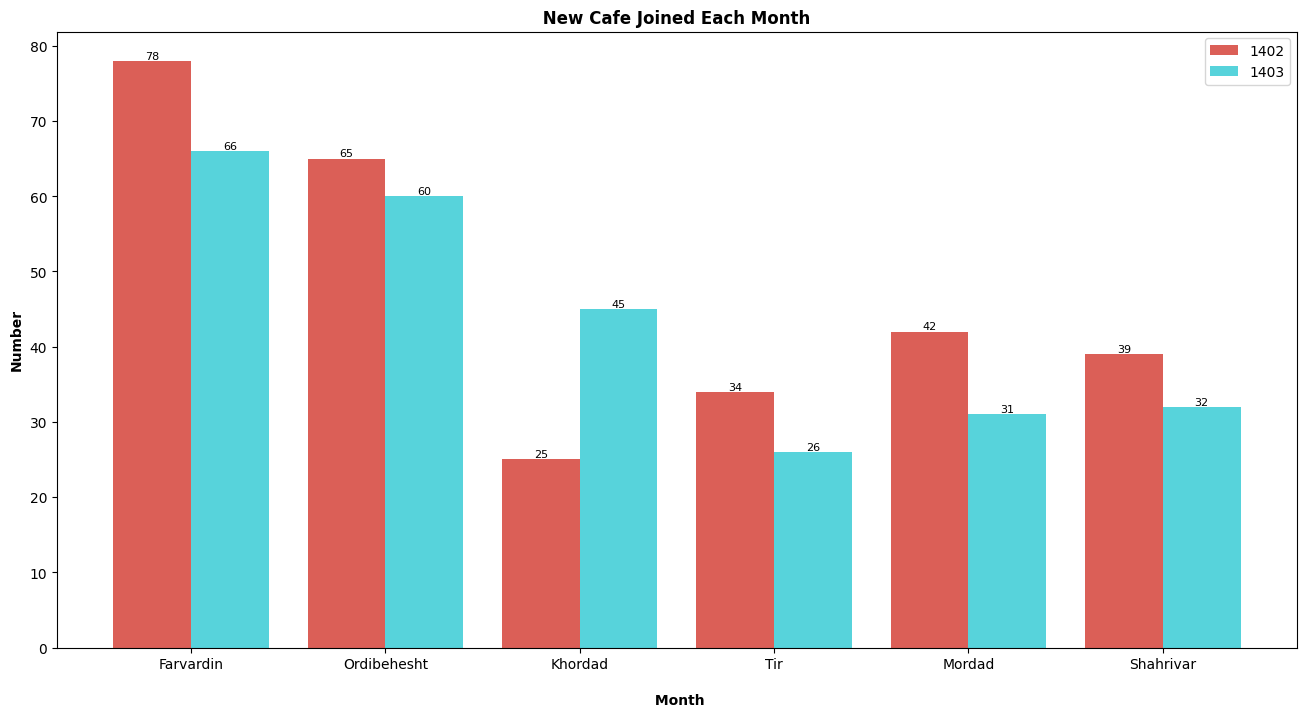

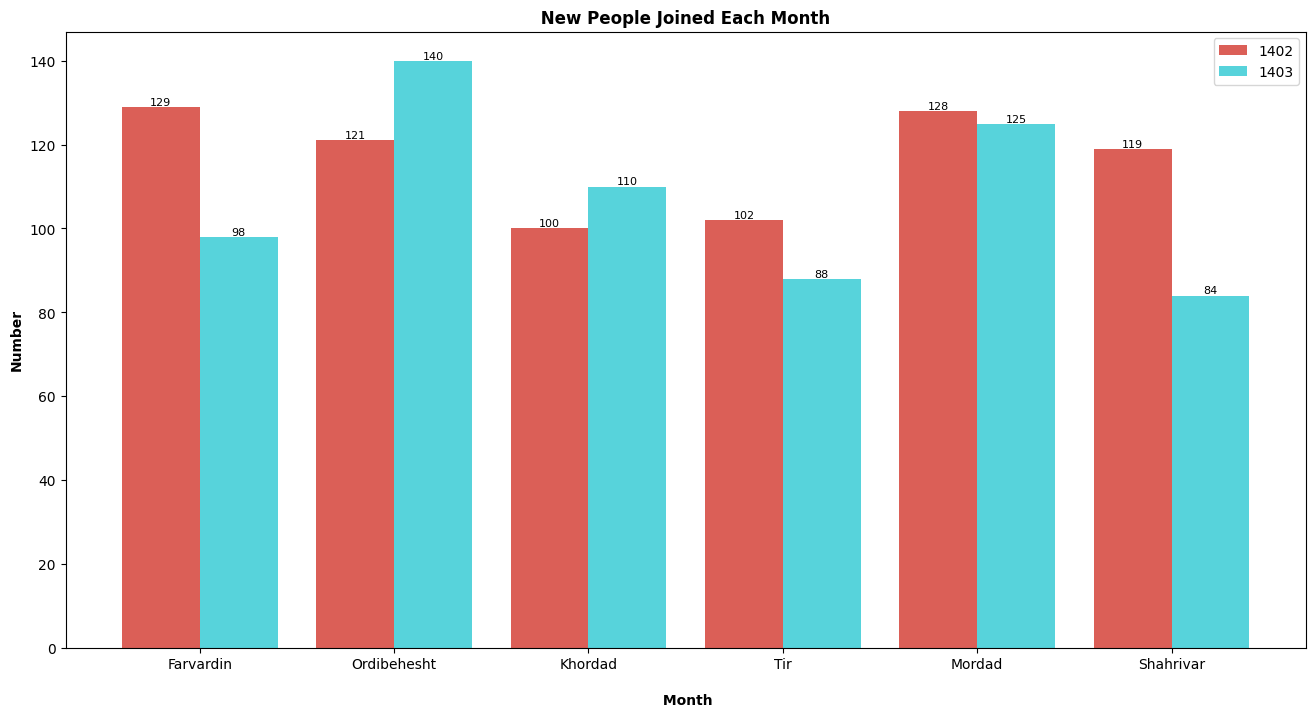

In [15]:
cafe_ids = {}
person_ids = {}

sale = df 

for i in set(sale["كد مشتري"].to_list()):
    try:
        customer_status = int(sale[sale["كد مشتري"] == i ]["كد گروه مشتري"].to_list()[0])
        year = int(sale[sale["كد مشتري"] == i ]["تاريخ"].to_list()[0][:4])
        month = int(sale[sale["كد مشتري"] == i ]["تاريخ"].to_list()[0][5:7])
        if customer_status == 2:
                cafe_ids[i] = {"year": year, "month": month}

        elif customer_status == 1:
                person_ids[i] = {"year": year, "month": month}
    except:
        continue

cafe_ids_df = pd.DataFrame(cafe_ids).T
person_ids_df = pd.DataFrame(person_ids).T


df_1401 = person_ids_df[person_ids_df["year"]==1402]
new_customers_dict = {}
for i in set(df_1401["month"].to_list()):
    new_customers_dict[f"{i}"] = len(df_1401[df_1401["month"] == i])
person_ids_1401 = pd.DataFrame(pd.Series(new_customers_dict)).reset_index()
person_ids_1401["year"] = 1402
person_ids_1401["customer_Type"] = "Personal"


df_1402 = person_ids_df[person_ids_df["year"]==1403]
new_customers_dict = {}
for i in set(df_1402["month"].to_list()):
    new_customers_dict[f"{i}"] = len(df_1402[df_1402["month"] == i])
person_ids_1402 = pd.DataFrame(pd.Series(new_customers_dict)).reset_index()
person_ids_1402["year"] = 1403
person_ids_1402["customer_Type"] = "Personal"



df_1401 = cafe_ids_df[cafe_ids_df["year"]==1402]
new_customers_dict = {}
for i in set(df_1401["month"].to_list()):
    new_customers_dict[f"{i}"] = len(df_1401[df_1401["month"] == i])
cafe_ids_1401 = pd.DataFrame(pd.Series(new_customers_dict)).reset_index()
cafe_ids_1401["year"] = 1402
cafe_ids_1401["customer_Type"] = "Cafe"


df_1402 = cafe_ids_df[cafe_ids_df["year"]==1403]
new_customers_dict = {}
for i in set(df_1402["month"].to_list()):
    new_customers_dict[f"{i}"] = len(df_1402[df_1402["month"] == i])
cafe_ids_1402 = pd.DataFrame(pd.Series(new_customers_dict)).reset_index()
cafe_ids_1402["year"] = 1403
cafe_ids_1402["customer_Type"] = "Cafe"


cafe_ids_1401_list = cafe_ids_1401[0].to_list()
cafe_ids_1402_list = cafe_ids_1402[0].to_list()

person_ids_1401_list = person_ids_1401[0].to_list()
person_ids_1402_list = person_ids_1402[0].to_list()



group = ['Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar']

num_colors = 2  # Number of colors in the palette
palette = sns.color_palette("hls", num_colors)
# Set the color cycle to use the random color palette
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=palette)


def bar_group(classes, values,string, width=0.8):
    plt.figure(figsize=(16,8))
    plt.xlabel('\n Month', weight='semibold')
    plt.ylabel('Number', weight='semibold')
    plt.title(f" New {string} Joined Each Month ",weight='semibold' )
    total_data = len(values)
    classes_num = np.arange(len(classes))
    for i in range(total_data):
        bars = plt.bar(classes_num - width / 2. + i / total_data * width, values[i], 
                width=width / total_data, align="edge", animated=0.4)
        for rect in bars:
            height = rect.get_height()
            plt.text(rect.get_x() + rect.get_width()/2.0, height,  f'{height}', ha='center', va='bottom', size=8)
    plt.xticks(classes_num, classes, size=10)
    plt.legend(['1402', '1403'])


bar_group(group, [cafe_ids_1401_list, cafe_ids_1402_list] , "Cafe")
bar_group(group, [person_ids_1401_list, person_ids_1402_list] , "People")

In [3]:
city_1402_df = pd.read_excel("/Users/mohammad/Downloads/اطلاعات مشتريان.xlsx")
df = pd.read_excel("/Users/mohammad/XAV/Departemant Financial/Receipt Database.xlsx")
df = df[df["ماه"] < 7]

def city(sale,city_df): 
    city_dict = {}
    for i in range(len(city_df)):
        code = city_df.loc[i, "كد"]
        customer_city = city_df.loc[i, "شهر"]
        city_dict[code] = customer_city

    sale["شهر"] = None
    for i in range(len(sale)):
        try:
            code = sale.loc[i, "كد مشتري"]
            sale.loc[i,"شهر"] = city_dict[code]
        except:
            continue
    return sale

def modify_string(text):
    if isinstance(text, str) and "مركزي" in text:
        modified_text = text.replace("مركزي", "").split()
        modified_text = " ".join(modified_text)
        return modified_text
    else:
        return text
city_1402_df["شهر"] = city_1402_df["شهر"].apply(modify_string)

df_1 = city(df,city_1402_df)
df = df_1

mask_1403 = df["تاريخ"].str.startswith("1403")
df_1403 = df[mask_1403]

mask_1402 = df["تاريخ"].str.startswith("1402")
df_1402 = df[mask_1402]

def top_city_contribution(sale,sale1, string):
    city = sale["شهر"].value_counts().to_dict()
    total_kg_sale = round((sum(sale["مقدار-فرعي"].to_list())) / 1000,3)
    total_kg_sale_last = round((sum(sale1["مقدار-فرعي"].to_list())) / 1000,3)
    city_dict = {}
    for i in city.keys():
        try:
            series_df = sale1[sale1["شهر"] == i]
            # their Total KG
            kg = round(sum(series_df["مقدار-فرعي"].to_list()) / 1000,3)
            city_dict[i] = {"last_year_kg" : kg, "contribution": kg/total_kg_sale_last}
        except:
            continue
        
    for i in city_dict.keys():
        if i in sale["شهر"].value_counts():
            last_year_kg = round(sum(sale[sale["شهر"] == i]["مقدار-فرعي"].to_list()) / 1000,3)
            city_dict[i].update({"this_year_kg": last_year_kg})
            try:
                engagement = round((((city_dict[i]["this_year_kg"] - city_dict[i]["last_year_kg"]) / city_dict[i]["last_year_kg"]) * city_dict[i]["contribution"])*100,2)
                city_dict[i].update({"engagement": engagement })

            except:
                continue
            
        else:
            continue

    engagement_dict = {} 
    for i in city_dict.keys():
        try:
            value = city_dict[i]["engagement"]
            engagement_dict.update({i: value})
        except:
            continue

    status = string
    sorted_dict = dict(sorted(engagement_dict.items(), key=lambda item: item[1], reverse=status))

    top_10 = dict(list(sorted_dict.items())[:10])

        # plot the output
    x = list(top_10.keys())
    y = list(top_10.values())

    # Create a ColumnDataSource
    colors = ["#"+''.join([random.choice('0123456789ABCDEF') for j in range(6)]) for i in range(len(x))]
    source = ColumnDataSource(data=dict(x=x, y=y, color=colors))

    # Create the figure
    p = figure(x_range=x, height=600, width=1000 ,title= "Weighted Growth of Each City",
            toolbar_location=None, tools="")

    # Render the bars
    p.vbar(x='x', top='y', width=0.5, source=source, color="color")

    # Customize the plot
    p.xgrid.grid_line_color = None
    p.xaxis.major_label_orientation = 45  # Adjust the angle of the x-axis labels
    if string == True:
        yoffset = 10
    else:
        yoffset = -10
    for i, value in enumerate(y):
        label = Label(x=i, y=value, text=str(value) + "%", text_baseline='middle', text_align='center',text_font_size="7pt",
                      x_offset=40, y_offset= yoffset)
        p.add_layout(label)

    # Show the plot1
    output_notebook()
    show(p)

top_city_contribution(df_1403,df_1402,True)
top_city_contribution(df_1403,df_1402,False)

Loading BokehJS ...

Loading BokehJS ...

# Cafe Segmentation

In [1]:
mask_1403 = df["تاريخ"].str.startswith("1403")
df_1403 = df[mask_1403]

# selecting cafes buy list 
df_1403 = df_1403[df_1403["كد گروه مشتري"]==2]

# creating a dict for each cafe 
cafe_list = set(df_1403["مشتري"].to_list())
cafe_dict = {}
for i in cafe_list:
    cafe_df = df_1403[df_1403["مشتري"]==i]
    cafe_buy = round(sum(cafe_df["مقدار-فرعي"].to_list())/1000,3)
    cafe_dict[i] = cafe_buy


# creatng data frame of cafes
cafe_df = pd.DataFrame(list(cafe_dict.items()), columns=['Cafe', 'KG-6'])
# deleting less than 10kg cafes
cafe_df = cafe_df[cafe_df["KG-6"]>10]
# ading segment to each cafe
cafe_df['segment_percentile'] = pd.qcut(cafe_df['KG-6'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
cafe_df["receipt_count"] = None
cafe_df["last_receipt_days_passed"] = None

# Score recency, frequency, and monetary into 1-5 scales
cafe_df['R_score'] = pd.qcut(cafe_df['last_receipt_days_passed'], 5, labels=[5, 4, 3, 2, 1])
cafe_df['F_score'] = pd.qcut(cafe_df['receipt_count'], 5, labels=[1, 2, 3, 4, 5])
cafe_df['M_score'] = pd.qcut(cafe_df['KG-6'], 5, labels=[1, 2, 3, 4, 5])


# Normalize the buying amounts for K-Means
cafe_df['buying_amount_normalized'] = (cafe_df['KG-6'] - cafe_df['KG-6'].mean()) / cafe_df['KG-6'].std()

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=0).fit(cafe_df[['buying_amount_normalized']])
cafe_df['cluster'] = kmeans.labels_

# Visualize the clusters
plt.scatter(cafe_df.index, cafe_df['KG-6'], c=cafe_df['cluster'])
plt.xlabel('Cafe Index')
plt.ylabel('Buying Amount')
plt.title('K-Means Clustering of Cafes Based on Buying Amount')
plt.show()




NameError: name 'df' is not defined